LAB TASK: TCP Congestion Control Simulation

Question:
Using a TCP congestion control simulator (Python or any tool of your choice), simulate and analyze TCP Reno under three different packet-loss conditions:

0.1% loss
1% loss
2% loss

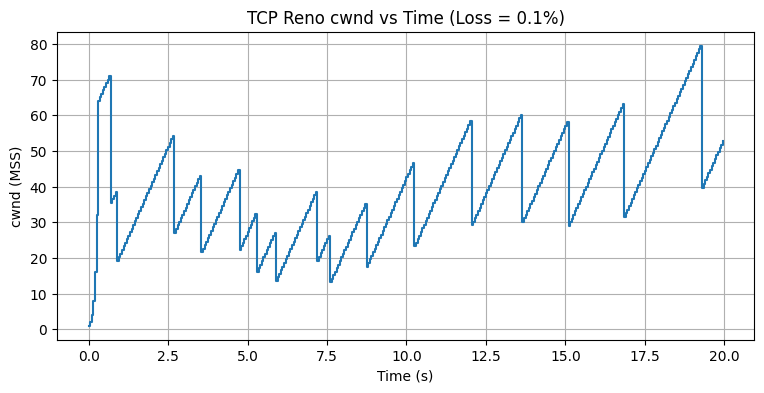

Loss 0.1% → Throughput: 778.05 MSS/s


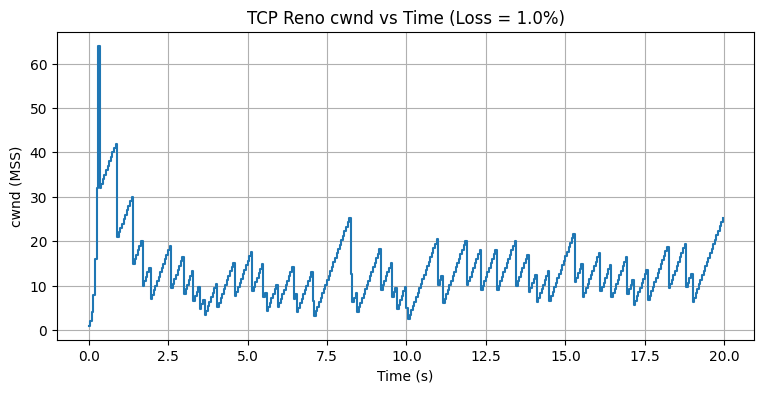

Loss 1.0% → Throughput: 258.70 MSS/s


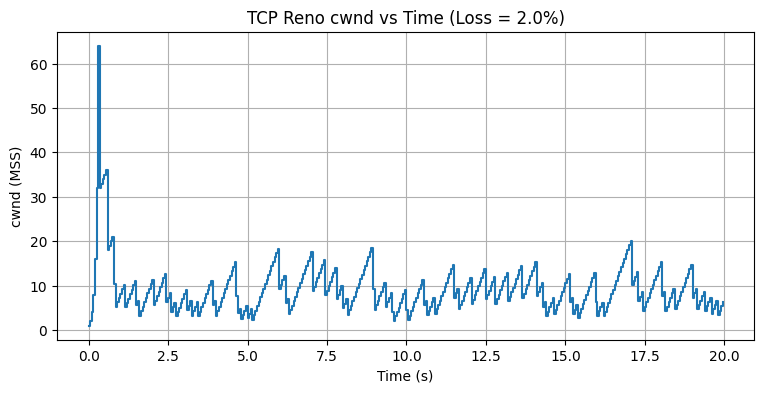

Loss 2.0% → Throughput: 177.20 MSS/s


In [3]:
import matplotlib.pyplot as plt
import random

RTT = 0.05
sim_time = 20.0
mss = 1.0
packets_per_seg = 1

algorithm = "reno"
initial_cwnd = 1.0
ssthresh_init = 64.0

def simulate(loss_prob):
    t = 0.0
    cwnd = initial_cwnd
    ssthresh = ssthresh_init

    time_steps = []
    cwnd_trace = []
    bytes_acked = 0.0

    def send_window(cwnd):
        segs = int(max(1, round(cwnd / mss)))
        lost = False
        acks = 0
        for _ in range(segs):
            if random.random() < loss_prob:
                lost = True
            else:
                acks += 1
        return lost, acks

    while t < sim_time:
        time_steps.append(t)
        cwnd_trace.append(cwnd)

        lost, acks = send_window(cwnd)
        bytes_acked += acks * mss

        if lost:
            ssthresh = max(cwnd / 2, 2)
            cwnd = max(cwnd / 2, 1)
        else:
            if cwnd < ssthresh:
                cwnd *= 2
            else:
                cwnd += 1

        cwnd = min(cwnd, 1000)
        t += RTT

    throughput = bytes_acked / sim_time
    return time_steps, cwnd_trace, throughput

# Run for 0.1%, 1%, 2%
loss_levels = [0.001, 0.01, 0.02]

for loss in loss_levels:
    t, cwnd, thr = simulate(loss)
    plt.figure(figsize=(9,4))
    plt.step(t, cwnd, where='post')
    plt.title(f"TCP Reno cwnd vs Time (Loss = {loss*100}%)")
    plt.xlabel("Time (s)")
    plt.ylabel("cwnd (MSS)")
    plt.grid(True)
    plt.show()

    print(f"Loss {loss*100}% → Throughput: {thr:.2f} MSS/s")
